In [1]:
# Import necessary core libraries for the machine learning pipeline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [2]:
# Load the healthcare dataset into a pandas DataFrame for analysis
df = pd.read_csv(r'C:\Users\rehan\OneDrive\Desktop\Data Science\6-Months-Data-Science\Medical-Disease\data\medical_disease.csv')

In [3]:
# Display a preview of the dataset to understand its structure, features, and values
df

,Age,Gender,BMI,BloodPressure,GlucoseLevel,Cholesterol,HeartRate,Smoking,Alcohol,PhysicalActivity,FamilyHistory,Disease
0,23,Male,17.5,102,177,161,88,No,No,Medium,No,Healthy
1,69,Male,31.1,118,256,147,92,No,No,High,Yes,Pre-Diabetes
2,61,Female,31.3,114,206,193,74,Yes,No,Medium,No,Healthy
3,47,Female,23.9,105,162,253,68,No,No,Low,No,Healthy
4,47,Male,28.3,148,121,280,84,No,Yes,High,No,Healthy
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,49,Male,27.1,177,183,268,59,No,No,High,No,Hypertension
9996,84,Male,29.2,142,215,145,77,No,Yes,High,Yes,Hypertension
9997,41,Male,22.8,177,265,133,71,No,No,Medium,Yes,Hypertension
9998,55,Male,29.0,126,241,298,57,No,No,Medium,Yes,Pre-Diabetes


In [4]:
# Check for data integrity by auditing duplicate records and missing values in the dataset
print("duplicate values : ", df.duplicated().sum())
print("null values : ", df.isnull().sum())

duplicate values :  0
null values :  Age                 0
Gender              0
BMI                 0
BloodPressure       0
GlucoseLevel        0
Cholesterol         0
HeartRate           0
Smoking             0
Alcohol             0
PhysicalActivity    0
FamilyHistory       0
Disease             0
dtype: int64


In [5]:
# Identify and review the distinct categories within the patient gender feature
df['Gender'].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

In [6]:
# Encode the categorical feature 'Gender' into a binary numerical format for machine learning compatibility
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

In [7]:
# Identify and review the distinct categories within the patient smoking feature
df['Smoking'].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [8]:
# Standardize the 'Smoking' text format and map the categorical values to binary labels
df['Smoking'] = df['Smoking'].str.strip().str.title().map({'No': 0, 'Yes': 1})

In [9]:
# Identify and review the distinct categories within the patient Alcohal feature
df['Alcohol'].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [10]:
# Standardize the 'Alcohol' text format and map the categorical values to binary labels
df['Alcohol'] = df['Alcohol'].str.strip().str.title().map({'No': 0, 'Yes': 1})

In [11]:
# Identify and review the distinct categories within the patient PhysicalActivity feature
df['PhysicalActivity'].unique()

<StringArray>
['Medium', 'High', 'Low']
Length: 3, dtype: str

In [12]:
# Standardize the 'PhysicalActivity' text format and map the categorical values to binary labels
df['PhysicalActivity']=df['PhysicalActivity'].str.strip().str.title().map({'Medium':2,'High':3,'Low':1})

In [13]:
# Identify and review the distinct categories within the patient FamilyHistory feature
df['FamilyHistory'].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [14]:
# Standardize the 'FamilyHistory' text format and map the categorical values to binary labels
df['FamilyHistory']=df['FamilyHistory'].str.strip().str.title().map({'No':0,'Yes':1})

In [15]:
# Identify and review the distinct categories within the patient Disease feature
df['Disease'].unique()

<StringArray>
['Healthy', 'Pre-Diabetes', 'Hypertension', 'Heart Disease', 'Diabetes']
Length: 5, dtype: str

In [16]:
# Standardize the 'Disease' text format and map the categorical values to binary labels
df['Disease']=df['Disease'].str.strip().str.title().map({'Healthy':1,'Pre-Diabetes':2,'Hypertension':3,'Heart Disease':4,'Diabetes':5})

In [17]:
# Display a preview of the dataset to verify successful categorical-to-numerical encoding
df

,Age,Gender,BMI,BloodPressure,GlucoseLevel,Cholesterol,HeartRate,Smoking,Alcohol,PhysicalActivity,FamilyHistory,Disease
0,23,1,17.5,102,177,161,88,0,0,2,0,1
1,69,1,31.1,118,256,147,92,0,0,3,1,2
2,61,0,31.3,114,206,193,74,1,0,2,0,1
3,47,0,23.9,105,162,253,68,0,0,1,0,1
4,47,1,28.3,148,121,280,84,0,1,3,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,49,1,27.1,177,183,268,59,0,0,3,0,3
9996,84,1,29.2,142,215,145,77,0,1,3,1,3
9997,41,1,22.8,177,265,133,71,0,0,2,1,3
9998,55,1,29.0,126,241,298,57,0,0,2,1,2


In [18]:
# Separate features by dropping the target variable 'Disease' from the dataset
x = df.drop('Disease', axis=1)

In [19]:
# Display the feature matrix (independent variables) to verify the final predictor variables
x

,Age,Gender,BMI,BloodPressure,GlucoseLevel,Cholesterol,HeartRate,Smoking,Alcohol,PhysicalActivity,FamilyHistory
0,23,1,17.5,102,177,161,88,0,0,2,0
1,69,1,31.1,118,256,147,92,0,0,3,1
2,61,0,31.3,114,206,193,74,1,0,2,0
3,47,0,23.9,105,162,253,68,0,0,1,0
4,47,1,28.3,148,121,280,84,0,1,3,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,49,1,27.1,177,183,268,59,0,0,3,0
9996,84,1,29.2,142,215,145,77,0,1,3,1
9997,41,1,22.8,177,265,133,71,0,0,2,1
9998,55,1,29.0,126,241,298,57,0,0,2,1


In [20]:
# Extract the target variable 'Disease' into a standalone vector (dependent variable)
y = df[['Disease']]

In [21]:
# Display the target variable vector to verify the categorical disease labels
y

,Disease
0,1
1,2
2,1
3,1
4,1
...,...
9995,3
9996,3
9997,3
9998,2


In [22]:
# Check the dimensions of the dataset to verify the total number of rows (patients) and columns (features)
df.shape

(10000, 12)

In [23]:
# View the first five rows of the dataset to inspect the initial rows of the encoded data
df.head()

,Age,Gender,BMI,BloodPressure,GlucoseLevel,Cholesterol,HeartRate,Smoking,Alcohol,PhysicalActivity,FamilyHistory,Disease
0,23,1,17.5,102,177,161,88,0,0,2,0,1
1,69,1,31.1,118,256,147,92,0,0,3,1,2
2,61,0,31.3,114,206,193,74,1,0,2,0,1
3,47,0,23.9,105,162,253,68,0,0,1,0,1
4,47,1,28.3,148,121,280,84,0,1,3,0,1


In [24]:
# View the last five rows of the dataset to verify data consistency across the final records
df.tail()

,Age,Gender,BMI,BloodPressure,GlucoseLevel,Cholesterol,HeartRate,Smoking,Alcohol,PhysicalActivity,FamilyHistory,Disease
9995,49,1,27.1,177,183,268,59,0,0,3,0,3
9996,84,1,29.2,142,215,145,77,0,1,3,1,3
9997,41,1,22.8,177,265,133,71,0,0,2,1,3
9998,55,1,29.0,126,241,298,57,0,0,2,1,2
9999,59,1,32.2,151,162,225,93,0,0,3,1,2


In [25]:
# Generate a comprehensive summary of the DataFrame, including column data types, non-null counts, and memory usage
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               10000 non-null  int64  
 1   Gender            10000 non-null  int64  
 2   BMI               10000 non-null  float64
 3   BloodPressure     10000 non-null  int64  
 4   GlucoseLevel      10000 non-null  int64  
 5   Cholesterol       10000 non-null  int64  
 6   HeartRate         10000 non-null  int64  
 7   Smoking           10000 non-null  int64  
 8   Alcohol           10000 non-null  int64  
 9   PhysicalActivity  10000 non-null  int64  
 10  FamilyHistory     10000 non-null  int64  
 11  Disease           10000 non-null  int64  
dtypes: float64(1), int64(11)
memory usage: 937.6 KB


In [26]:
# Generate descriptive statistics summarizing the central tendency, dispersion, and shape of the dataset's distribution
df.describe()

,Age,Gender,BMI,BloodPressure,GlucoseLevel,Cholesterol,HeartRate,Smoking,Alcohol,PhysicalActivity,FamilyHistory,Disease
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,50.755300,0.501100,26.082000,135.023800,175.252000,219.313500,82.690100,0.297300,0.249400,1.901300,0.390800,1.655100
std,19.242137,0.500024,4.461098,26.249406,60.536159,57.940956,16.167628,0.457093,0.432687,0.693835,0.487954,0.988657
min,18.000000,0.000000,16.000000,90.000000,70.000000,120.000000,55.000000,0.000000,0.000000,1.000000,0.000000,1.000000
25%,34.000000,0.000000,23.000000,112.000000,123.000000,169.000000,69.000000,0.000000,0.000000,1.000000,0.000000,1.000000
50%,51.000000,1.000000,26.000000,135.000000,174.000000,219.000000,83.000000,0.000000,0.000000,2.000000,0.000000,1.000000
75%,67.000000,1.000000,29.100000,158.000000,227.000000,269.250000,97.000000,1.000000,0.000000,2.000000,1.000000,2.000000
max,84.000000,1.000000,44.700000,180.000000,280.000000,320.000000,110.000000,1.000000,1.000000,3.000000,1.000000,5.000000


In [27]:
# Check for duplicate records and missing (null) values to evaluate data quality
df.duplicated().sum()
df.isnull().sum()

Age                 0
Gender              0
BMI                 0
BloodPressure       0
GlucoseLevel        0
Cholesterol         0
HeartRate           0
Smoking             0
Alcohol             0
PhysicalActivity    0
FamilyHistory       0
Disease             0
dtype: int64

* save clean data

In [28]:
# df.to_csv("cleaned_data.csv", index=False)

C:\Users\rehan\AppData\Local\Temp\ipykernel_21100\570902729.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Disease', data=df, palette='Set2')


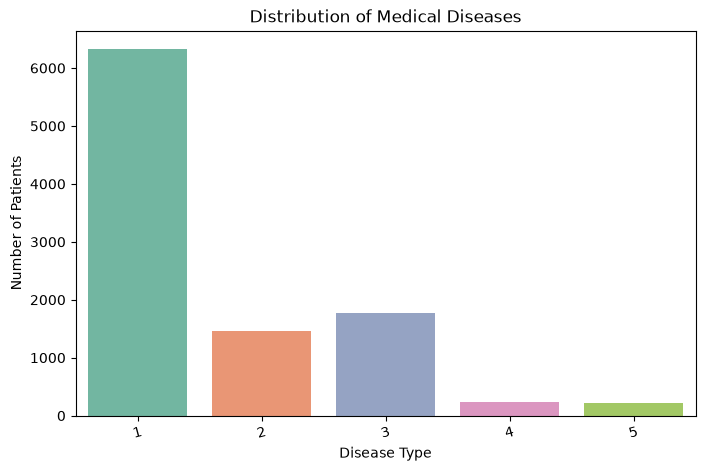

In [29]:
# Visualize the distribution of medical diseases using a count plot
plt.figure(figsize=(8, 5))
sns.countplot(x='Disease', data=df, palette='Set2')

plt.title("Distribution of Medical Diseases")
plt.xlabel("Disease Type")
plt.ylabel("Number of Patients")
plt.xticks(rotation=15)
plt.show()

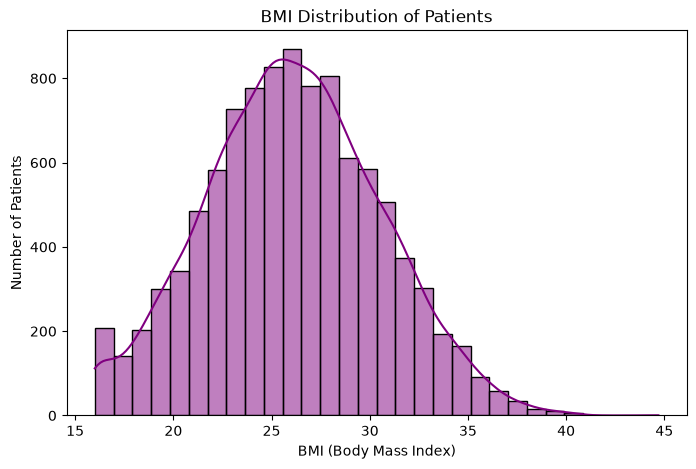

In [30]:
# Visualize the BMI distribution of patients using a histogram with a KDE curve
plt.figure(figsize=(8, 5))
sns.histplot(df['BMI'], bins=30, kde=True, color='purple')

plt.title("BMI Distribution of Patients")
plt.xlabel("BMI (Body Mass Index)")
plt.ylabel("Number of Patients")
plt.show()

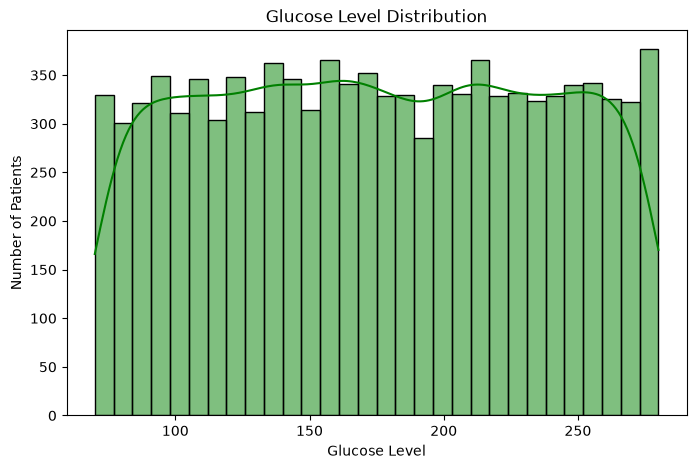

In [31]:
# Visualize the glucose level distribution of patients using a histogram with a KDE curve
plt.figure(figsize=(8, 5))
sns.histplot(df['GlucoseLevel'], bins=30, kde=True, color='green')

plt.title("Glucose Level Distribution")
plt.xlabel("Glucose Level")
plt.ylabel("Number of Patients")
plt.show()

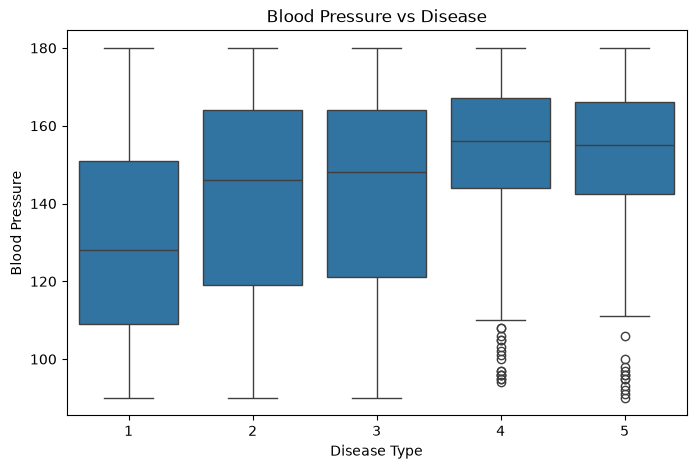

In [32]:
# Analyze the relationship between blood pressure and disease types using a box plot
plt.figure(figsize=(8, 5))
sns.boxplot(x='Disease', y='BloodPressure', data=df)

plt.title("Blood Pressure vs Disease")
plt.xlabel("Disease Type")
plt.ylabel("Blood Pressure")
plt.show()

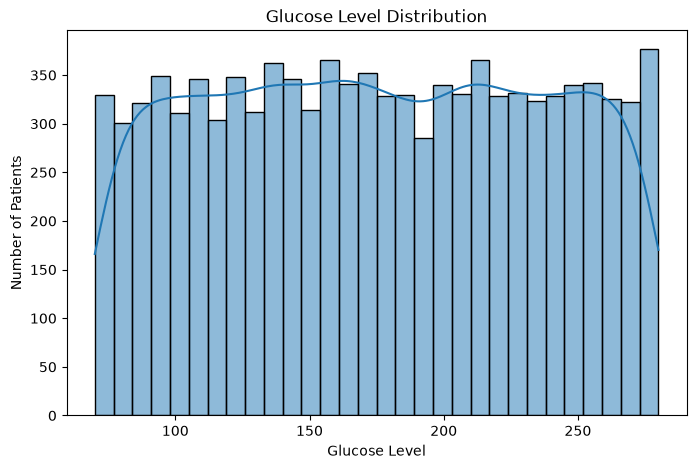

In [33]:
# Visualize the glucose level distribution of patients using a histogram with a KDE curve
plt.figure(figsize=(8, 5))
sns.histplot(df['GlucoseLevel'], bins=30, kde=True)

plt.title("Glucose Level Distribution")
plt.xlabel("Glucose Level")
plt.ylabel("Number of Patients")
plt.show()

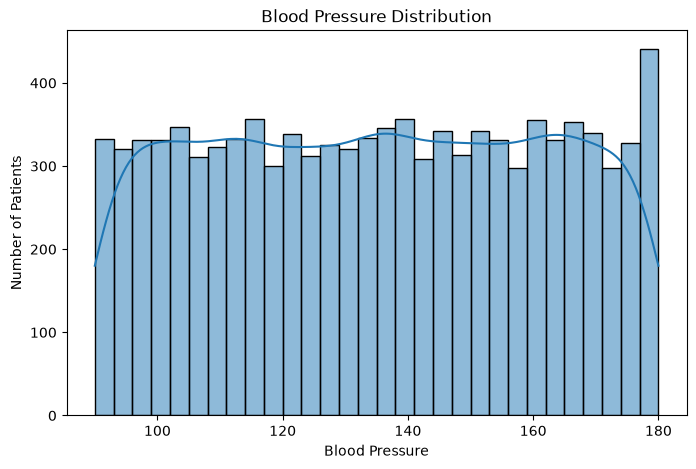

In [34]:
# Visualize the blood pressure distribution of patients using a histogram with a KDE curve
plt.figure(figsize=(8, 5))
sns.histplot(df['BloodPressure'], bins=30, kde=True)

plt.title("Blood Pressure Distribution")
plt.xlabel("Blood Pressure")
plt.ylabel("Number of Patients")
plt.show()

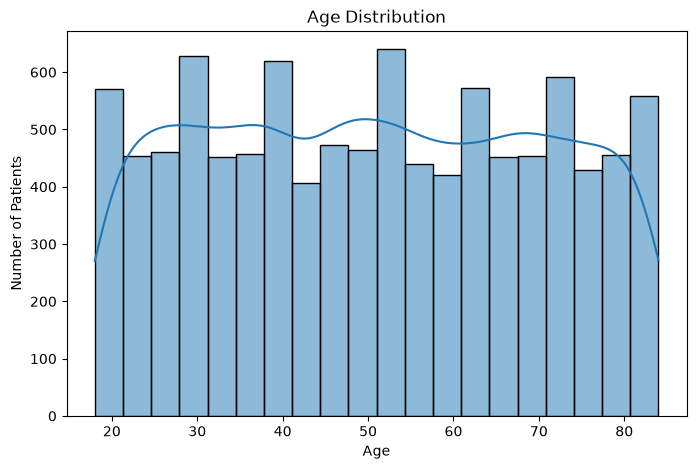

In [35]:
# Visualize the age distribution of patients using a histogram with a KDE curve
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=20, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.show()

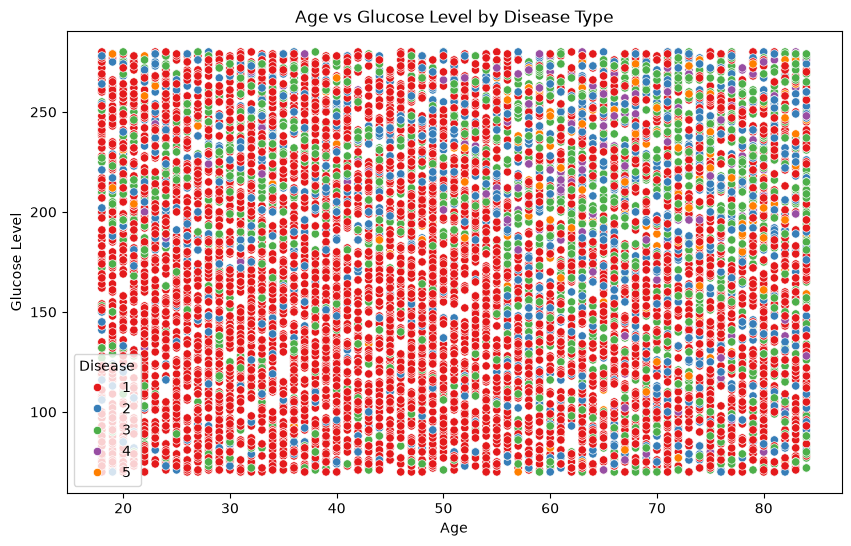

In [36]:
# Analyze the relationship between age and glucose levels across different disease types using a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='GlucoseLevel', hue='Disease', data=df, palette='Set1')

plt.title("Age vs Glucose Level by Disease Type")
plt.xlabel("Age")
plt.ylabel("Glucose Level")
plt.show()

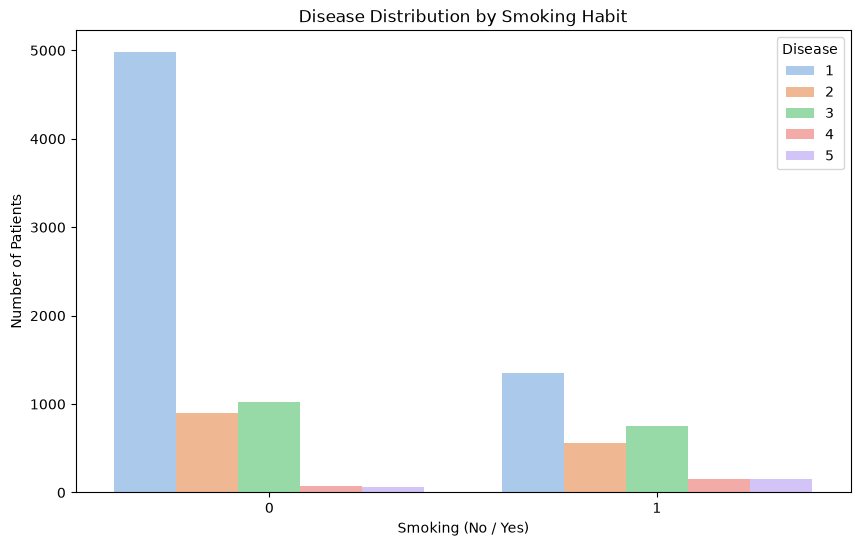

In [37]:
# Analyze the impact of smoking habits on disease distribution using a grouped count plot
plt.figure(figsize=(10, 6))
sns.countplot(x='Smoking', hue='Disease', data=df, palette='pastel')

plt.title("Disease Distribution by Smoking Habit")
plt.xlabel("Smoking (No / Yes)")
plt.ylabel("Number of Patients")
plt.show()

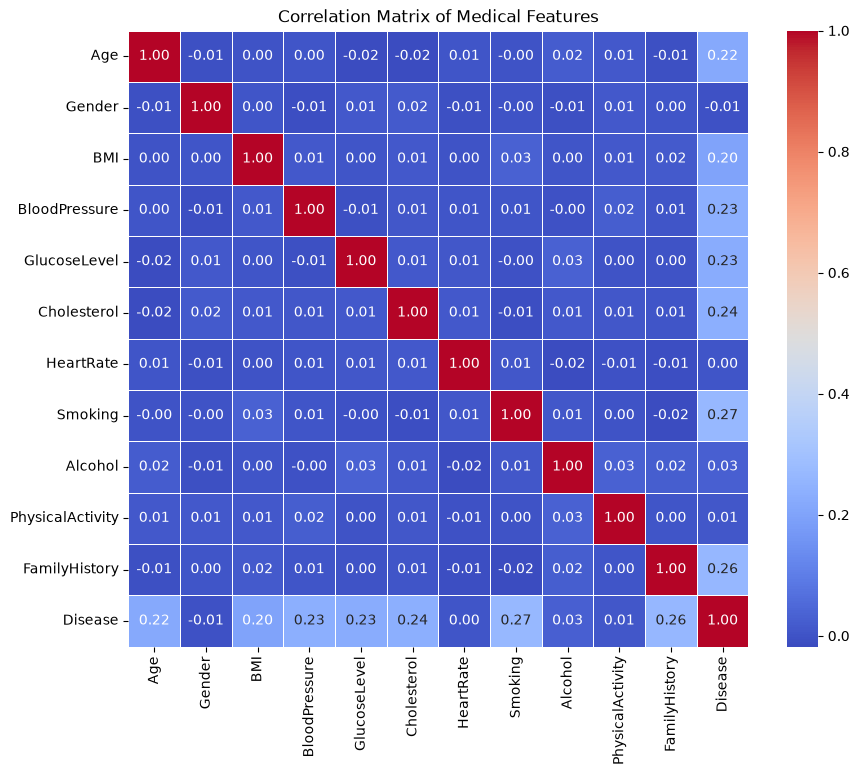

In [38]:
# Analyze the linear relationships between numeric medical features using a correlation matrix heatmap
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title("Correlation Matrix of Medical Features")
plt.show()

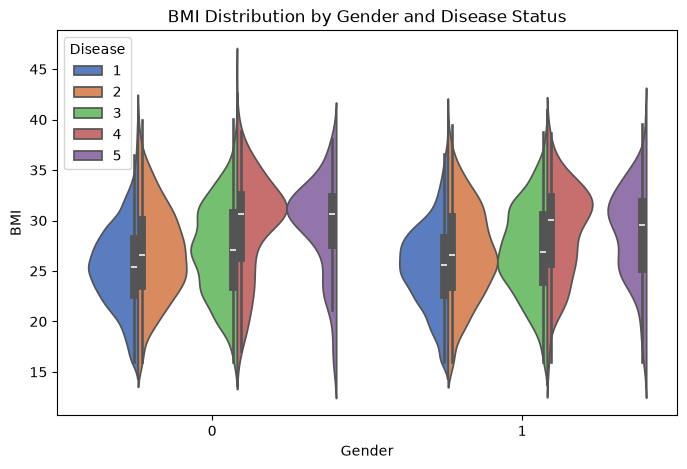

In [39]:
# Analyze BMI distribution across genders and disease status using a split violin plot
plt.figure(figsize=(8, 5))
sns.violinplot(x='Gender', y='BMI', hue='Disease', data=df, split=True, palette='muted')

plt.title("BMI Distribution by Gender and Disease Status")
plt.xlabel("Gender")
plt.ylabel("BMI")
plt.show()

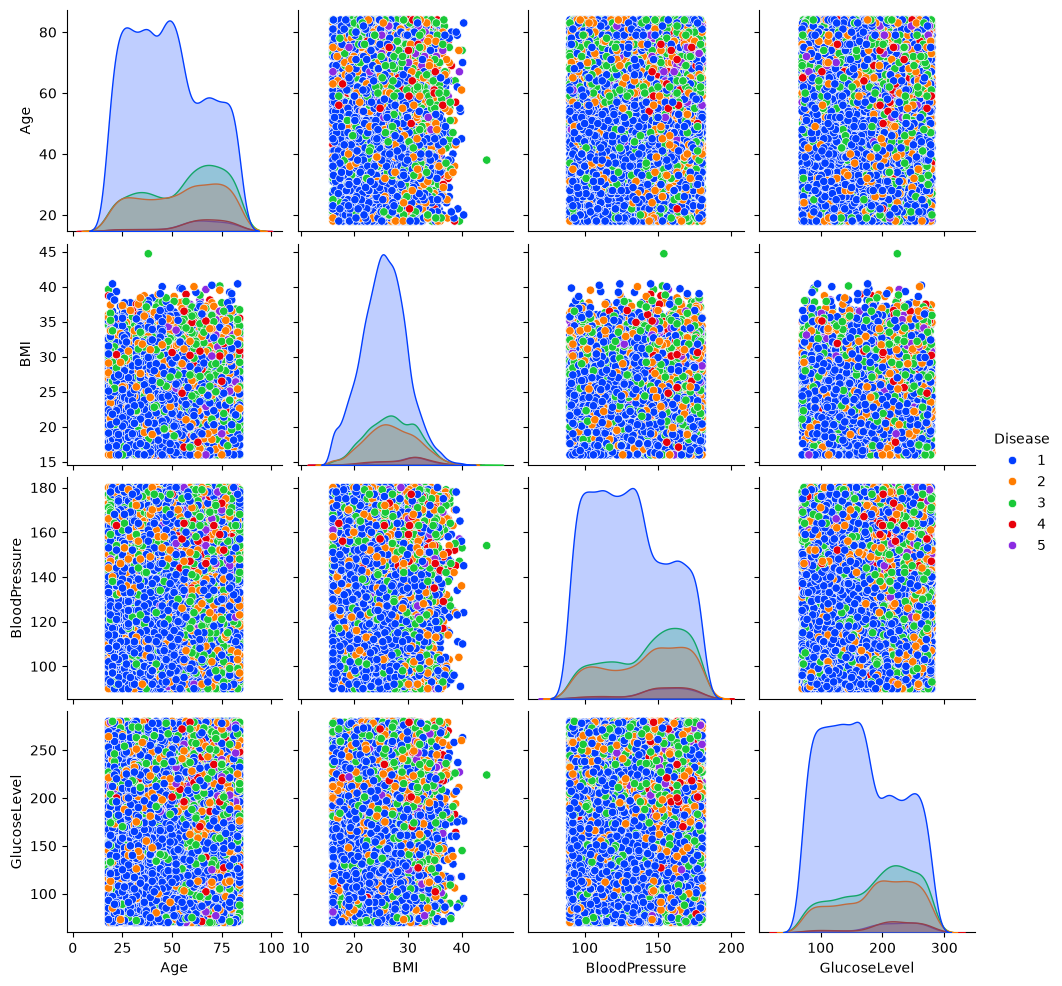

In [40]:
# Visualize pairwise relationships and distributions between key medical features across different disease types
main_features = ['Age', 'BMI', 'BloodPressure', 'GlucoseLevel', 'Disease']
sns.pairplot(df[main_features], hue='Disease', palette='bright')

plt.show()

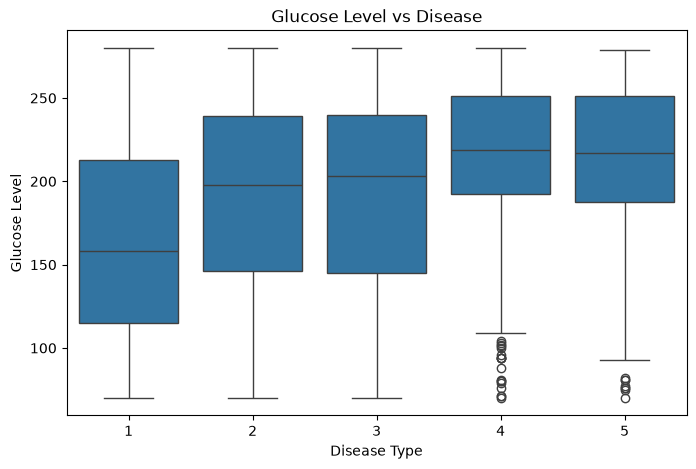

In [41]:
# Analyze the distribution and variations of glucose levels across different disease types using a box plot
plt.figure(figsize=(8, 5))
sns.boxplot(x='Disease', y='GlucoseLevel', data=df)

plt.title("Glucose Level vs Disease")
plt.xlabel("Disease Type")
plt.ylabel("Glucose Level")
plt.show()

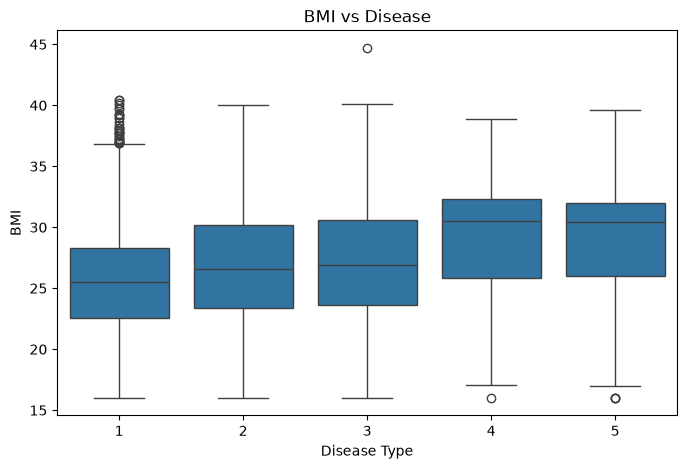

In [42]:
# Analyze the distribution and variations of BMI across different disease types using a box plot
plt.figure(figsize=(8, 5))
sns.boxplot(x='Disease', y='BMI', data=df)

plt.title("BMI vs Disease")
plt.xlabel("Disease Type")
plt.ylabel("BMI")
plt.show()

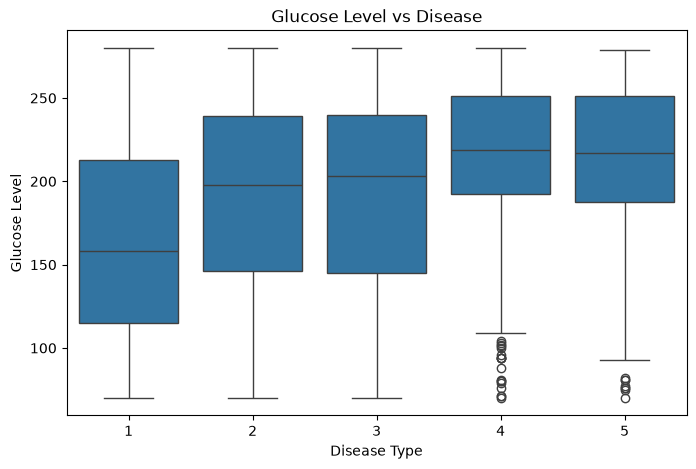

In [43]:
# Analyze the variance and median distribution of glucose levels across different disease types using a box plot
plt.figure(figsize=(8, 5))
sns.boxplot(x='Disease', y='GlucoseLevel', data=df)

plt.title("Glucose Level vs Disease")
plt.xlabel("Disease Type")
plt.ylabel("Glucose Level")
plt.show()

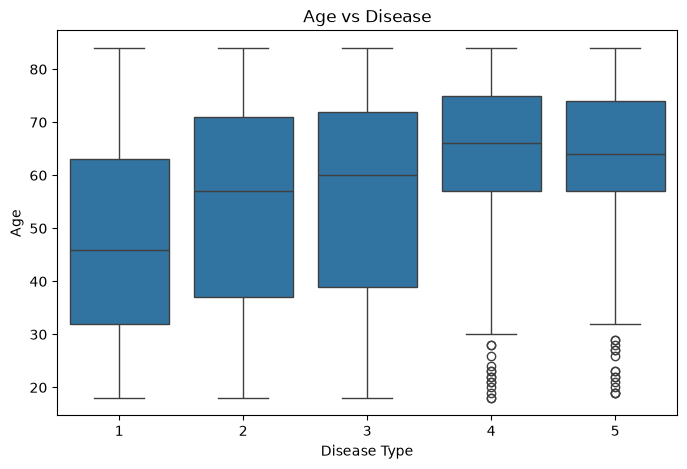

In [44]:
# Analyze the age distribution and median age variation across different disease types using a box plot
plt.figure(figsize=(8, 5))
sns.boxplot(x='Disease', y='Age', data=df)

plt.title("Age vs Disease")
plt.xlabel("Disease Type")
plt.ylabel("Age")
plt.show()

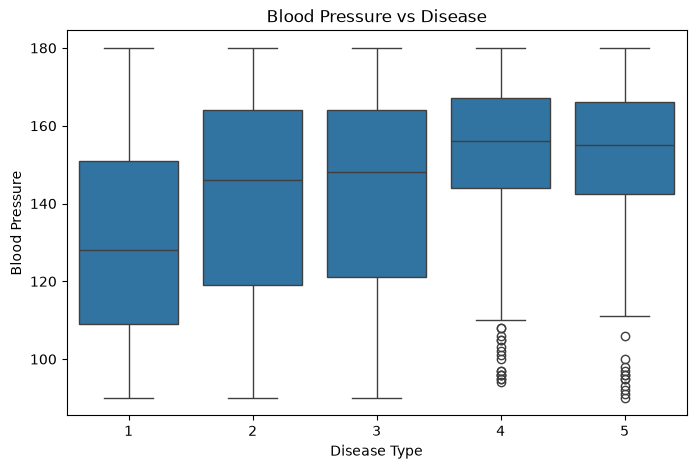

In [45]:
# Analyze the blood pressure distribution and median variation across different disease types using a box plot
plt.figure(figsize=(8, 5))
sns.boxplot(x='Disease', y='BloodPressure', data=df)

plt.title("Blood Pressure vs Disease")
plt.xlabel("Disease Type")
plt.ylabel("Blood Pressure")
plt.show()

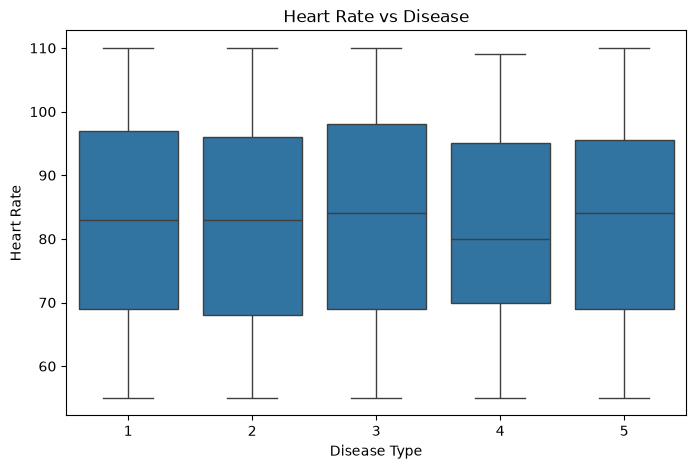

In [46]:
# Analyze the heart rate distribution and median variation across different disease types using a box plot
plt.figure(figsize=(8, 5))
sns.boxplot(x='Disease', y='HeartRate', data=df)

plt.title("Heart Rate vs Disease")
plt.xlabel("Disease Type")
plt.ylabel("Heart Rate")
plt.show()

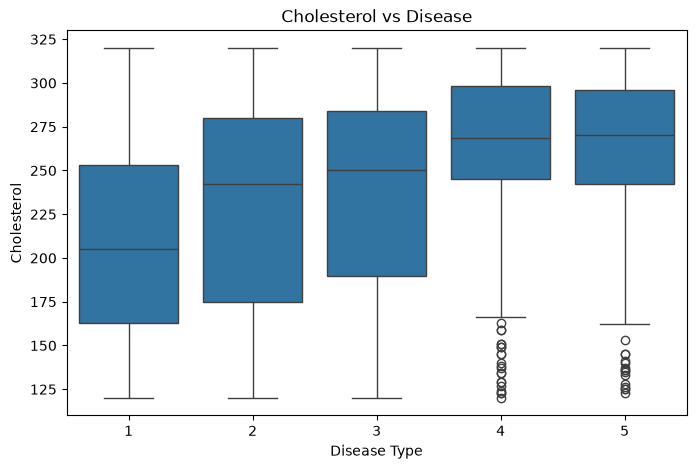

In [47]:
# Analyze the cholesterol level distribution and median variation across different disease types using a box plot
plt.figure(figsize=(8, 5))
sns.boxplot(x='Disease', y='Cholesterol', data=df)

plt.title("Cholesterol vs Disease")
plt.xlabel("Disease Type")
plt.ylabel("Cholesterol")
plt.show()

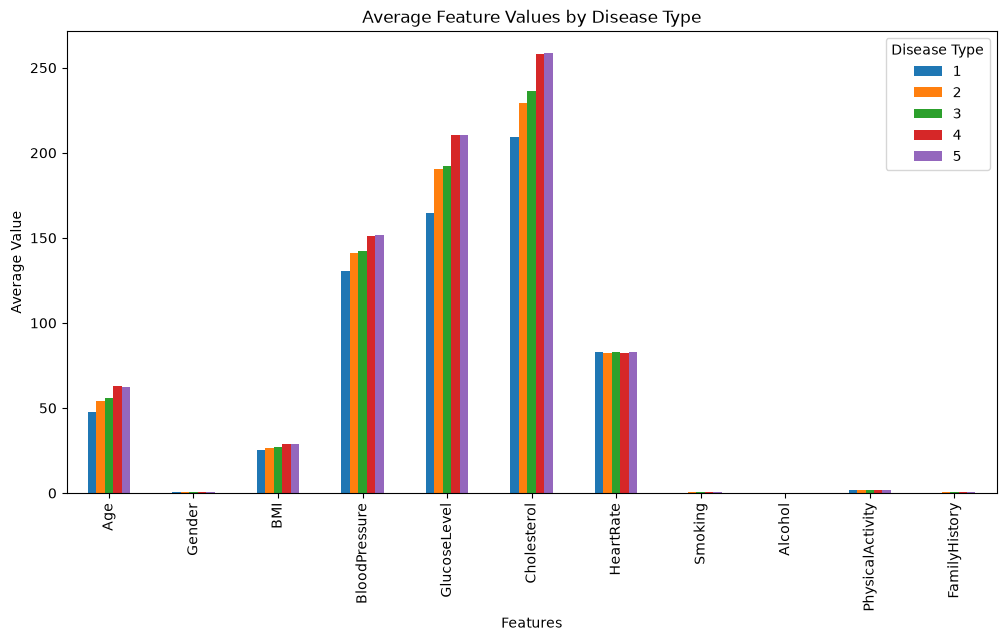

In [48]:
# Compare the average values of all numeric features across different disease types using a transposed bar chart
df.groupby('Disease').mean(numeric_only=True).T.plot(kind='bar', figsize=(12, 6))

plt.title("Average Feature Values by Disease Type")
plt.xlabel("Features")
plt.ylabel("Average Value")
plt.legend(title="Disease Type")
plt.show()

In [49]:
# Correlation of features with target variable (Disease)
df.corr(numeric_only=True)['Disease'].sort_values(ascending=False)

Disease             1.000000
Smoking             0.266760
FamilyHistory       0.264085
Cholesterol         0.235721
BloodPressure       0.234556
GlucoseLevel        0.228177
Age                 0.217964
BMI                 0.200241
Alcohol             0.027629
PhysicalActivity    0.007958
HeartRate           0.004994
Gender             -0.005605
Name: Disease, dtype: float64

In [50]:
# Final check for missing values in dataset
df.isnull().sum().sort_values(ascending=False)

Age                 0
Gender              0
BMI                 0
BloodPressure       0
GlucoseLevel        0
Cholesterol         0
HeartRate           0
Smoking             0
Alcohol             0
PhysicalActivity    0
FamilyHistory       0
Disease             0
dtype: int64

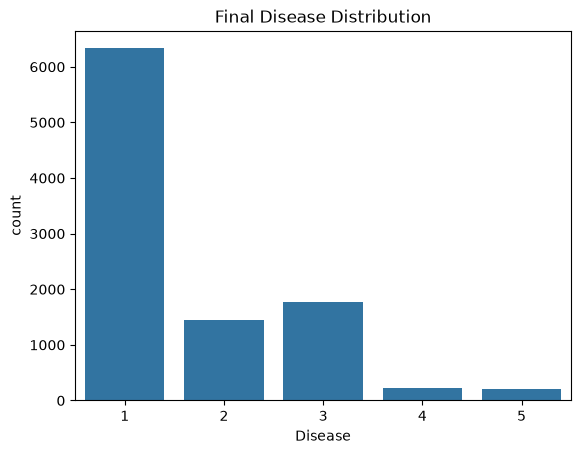

In [51]:
# Final quick view of medical disease distribution
sns.countplot(x='Disease', data=df)
plt.title("Final Disease Distribution")
plt.show()

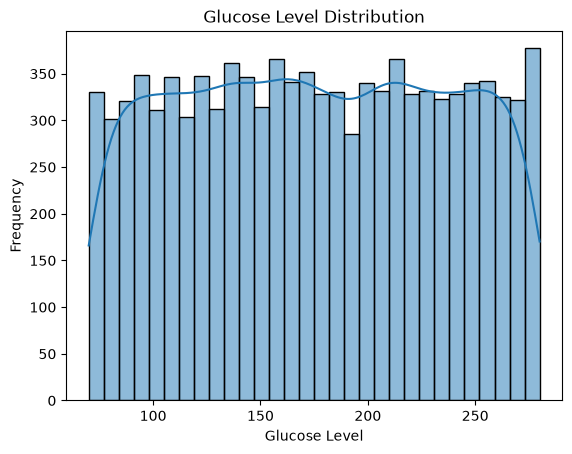

In [52]:
# Plot the distribution of the Glucose Level feature
sns.histplot(df['GlucoseLevel'], bins=30, kde=True)
plt.title('Glucose Level Distribution')
plt.xlabel('Glucose Level')
plt.ylabel('Frequency')
plt.show()

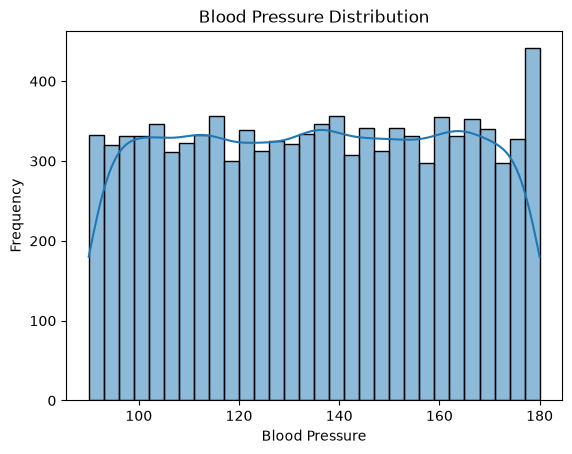

In [53]:
# Plot the distribution of the Blood Pressure feature
sns.histplot(df['BloodPressure'], bins=30, kde=True)
plt.title('Blood Pressure Distribution')
plt.xlabel('Blood Pressure')
plt.ylabel('Frequency')
plt.show()

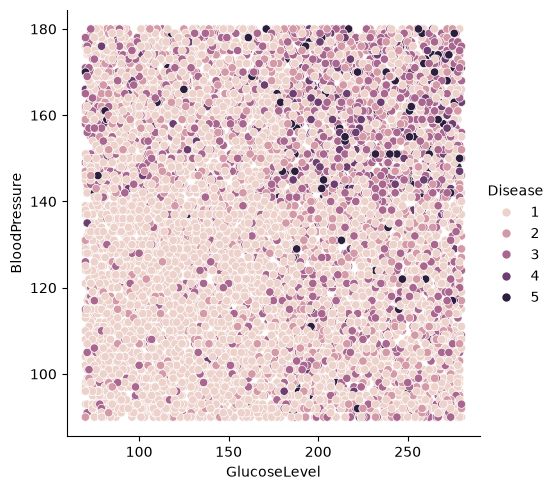

In [54]:
# Visualize the relationship between Glucose Level and Blood Pressure, with colors indicating disease status
sns.relplot(
    data=df,
    x='GlucoseLevel',
    y='BloodPressure',
    hue='Disease'
)

------------

In [55]:
x

,Age,Gender,BMI,BloodPressure,GlucoseLevel,Cholesterol,HeartRate,Smoking,Alcohol,PhysicalActivity,FamilyHistory
0,23,1,17.5,102,177,161,88,0,0,2,0
1,69,1,31.1,118,256,147,92,0,0,3,1
2,61,0,31.3,114,206,193,74,1,0,2,0
3,47,0,23.9,105,162,253,68,0,0,1,0
4,47,1,28.3,148,121,280,84,0,1,3,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,49,1,27.1,177,183,268,59,0,0,3,0
9996,84,1,29.2,142,215,145,77,0,1,3,1
9997,41,1,22.8,177,265,133,71,0,0,2,1
9998,55,1,29.0,126,241,298,57,0,0,2,1


In [56]:
y

,Disease
0,1
1,2
2,1
3,1
4,1
...,...
9995,3
9996,3
9997,3
9998,2


* train test split

In [57]:
# Import train_test_split and SMOTE for data preparation
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# Split the dataset into training and testing sets with stratification
X_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.20, random_state=42, stratify=y
)

In [58]:
# Flatten the training target variable into a one-dimensional array
y_target = y_train.values.ravel() if hasattr(y_train, 'values') else np.array(y_train).ravel()

* data balance

In [59]:
# Apply SMOTE exclusively on the training set to handle class imbalance safely
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_target)

In [60]:
# Normalize the balanced training features and test features using StandardScaler
scaler = StandardScaler()
X_train_bal_scaled = scaler.fit_transform(X_train_bal)
x_test_scaled = scaler.transform(x_test)

### Random Forest Classifier Model

In [61]:
# Import required libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import numpy as np

In [62]:
# Split the dataset into training and testing sets
X_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [63]:
# Convert target variables into one-dimensional arrays
y_train_final = (
    y_train.values.ravel()
    if hasattr(y_train, 'values')
    else np.array(y_train).ravel()
)

In [64]:
y_test_final = (
    y_test.values.ravel()
    if hasattr(y_test, 'values')
    else np.array(y_test).ravel()
)

In [65]:
# Initialize the final Random Forest model
rf_final = RandomForestClassifier(
    n_estimators=250,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

In [66]:
# Train the final model
rf_final.fit(X_train, y_train_final)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",250
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fea

In [67]:
# Make predictions on training and testing data
y_train_pred = rf_final.predict(X_train)
y_test_pred = rf_final.predict(x_test)

In [68]:
# Calculate training and testing accuracy
train_accuracy = accuracy_score(y_train_final, y_train_pred)
test_accuracy = accuracy_score(y_test_final, y_test_pred)

In [69]:
# Display model performance
print(f"Final Random Forest Training Accuracy : {train_accuracy * 100:.2f}%")
print(f"Final Random Forest Testing Accuracy  : {test_accuracy * 100:.2f}%")

Final Random Forest Training Accuracy : 83.45%
Final Random Forest Testing Accuracy  : 66.40%


In [70]:
# Display confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_final, y_test_pred))


Confusion Matrix:
[[996 158 111   1   0]
 [  8 152 128   2   1]
 [ 14 158 136  25  21]
 [  0   0   4  25  17]
 [  0   1   4  19  19]]


In [71]:
# Display classification report
print("\nTesting Classification Report:\n")
print(
    classification_report(
        y_test_final,
        y_test_pred,
        zero_division=0
    )
)


Testing Classification Report:

              precision    recall  f1-score   support

           1       0.98      0.79      0.87      1266
           2       0.32      0.52      0.40       291
           3       0.36      0.38      0.37       354
           4       0.35      0.54      0.42        46
           5       0.33      0.44      0.38        43

    accuracy                           0.66      2000
   macro avg       0.47      0.54      0.49      2000
weighted avg       0.74      0.66      0.69      2000



In [72]:
# Save the trained Random Forest model and scaler pkl

# joblib.dump(rf_final, "random_forest_model.pkl")
# joblib.dump(scaler, "scaler.pkl")

In [111]:
print("Features train data : ",rf_final.feature_names_in_)

Features train data :  ['Age' 'Gender' 'BMI' 'BloodPressure' 'GlucoseLevel' 'Cholesterol'
 'HeartRate' 'Smoking' 'Alcohol' 'PhysicalActivity' 'FamilyHistory']


In [133]:
import joblib
import numpy as np

# Load the final Random Forest model
loaded_model = joblib.load(
    r'C:\Users\rehan\OneDrive\Desktop\Data Science\6-Months-Data-Science\Medical-Disease\EDA\random_forest_model.pkl'
)

# Enter exactly 11 features
my_test_data = np.array([[76,1,29.7,122,183,244,92,0,0,1,0]])

# Make prediction WITHOUT scaler
prediction = loaded_model.predict(my_test_data)[0]

# Get probabilities
probability = loaded_model.predict_proba(my_test_data)[0]

# Disease mapping
disease_mapping = {
    1: 'Healthy (1)',
    2: 'Pre-Diabetes (2)',
    3: 'Hypertension (3)',
    4: 'Heart Disease (4)',
    5: 'Diabetes (5)'
}

# Convert prediction to disease name
result = disease_mapping[prediction]

# Get confidence
predicted_index = list(loaded_model.classes_).index(prediction)
confidence = probability[predicted_index] * 100

# Display result
print(f"✅ Predicted Disease: {result}")
print(f"📊 Confidence: {confidence:.2f}%")

✅ Predicted Disease: Pre-Diabetes (2)
📊 Confidence: 51.55%


c:\Users\rehan\OneDrive\Desktop\Data Science\boss\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\rehan\OneDrive\Desktop\Data Science\boss\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


### Gradient Boosting Classifier Model

In [73]:
# Import Gradient Boosting Classifier and evaluation metrics
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib

In [74]:
# Initialize the Gradient Boosting model with tuning parameters to prevent overfitting
gb_model = GradientBoostingClassifier(
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)

In [75]:
# Train the model using the balanced and scaled training data
gb_model.fit(X_train_bal_scaled, y_train_bal)

,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.8
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (i

In [76]:
# Make predictions on training and testing sets
y_train_pred_gb = gb_model.predict(X_train_bal_scaled)
y_test_pred_gb = gb_model.predict(x_test_scaled)

In [77]:
# Calculate training and testing accuracies
train_acc_gb = accuracy_score(y_train_bal, y_train_pred_gb)
test_acc_gb = accuracy_score(y_test, y_test_pred_gb)

In [78]:
# Accuracy
print(f"Gradient Boosting Training Accuracy : {train_acc_gb * 100:.2f}%")
print(f"Gradient Boosting Testing Accuracy  : {test_acc_gb * 100:.2f}%")

Gradient Boosting Training Accuracy : 66.22%
Gradient Boosting Testing Accuracy  : 56.95%


In [79]:
print("Testing Classification Report:\n")
print(classification_report(y_test, y_test_pred_gb, zero_division=0))

Testing Classification Report:

              precision    recall  f1-score   support

           1       0.87      0.75      0.80      1266
           2       0.23      0.27      0.25       291
           3       0.29      0.21      0.24       354
           4       0.11      0.37      0.17        46
           5       0.14      0.51      0.23        43

    accuracy                           0.57      2000
   macro avg       0.33      0.42      0.34      2000
weighted avg       0.64      0.57      0.60      2000



### Support Vector Machine (SVM)  

In [80]:
# Import Support Vector Classification and evaluation metrics
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [81]:
# Initialize the SVM model
svm_model = SVC(C=1.0, random_state=42)

In [82]:
# Train the model using the balanced and scaled training data
svm_model.fit(X_train_bal_scaled, y_train_bal)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [83]:
# Make predictions on training and testing sets
y_train_pred_svm = svm_model.predict(X_train_bal_scaled)
y_test_pred_svm = svm_model.predict(x_test_scaled)

In [84]:
# Calculate training and testing accuracies
train_acc_svm = accuracy_score(y_train_bal, y_train_pred_svm)
test_acc_svm = accuracy_score(y_test, y_test_pred_svm)

In [85]:
# Accuracy
print(f"SVM Training Accuracy : {train_acc_svm * 100:.2f}%")
print(f"SVM Testing Accuracy  : {test_acc_svm * 100:.2f}%")

SVM Training Accuracy : 71.06%
SVM Testing Accuracy  : 53.65%


In [86]:
print("\nTesting Classification Report:")
print(classification_report(y_test, y_test_pred_svm, zero_division=0))


Testing Classification Report:
              precision    recall  f1-score   support

           1       0.86      0.68      0.76      1266
           2       0.20      0.27      0.23       291
           3       0.28      0.31      0.30       354
           4       0.10      0.24      0.14        46
           5       0.14      0.35      0.20        43

    accuracy                           0.54      2000
   macro avg       0.32      0.37      0.33      2000
weighted avg       0.63      0.54      0.57      2000



### K-Nearest Neighbors (KNN)

In [87]:
# Import K-Nearest Neighbors Classifier and evaluation metrics
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

In [88]:
# Initialize the KNN model with an optimal number of neighbors to reduce overfitting
knn_model = KNeighborsClassifier(n_neighbors=11)

In [89]:
# Train the model using the balanced and scaled training data
knn_model.fit(X_train_bal_scaled, y_train_bal)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",11
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](5,)","[1,2,3,4,5]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [90]:
# Make predictions on training and testing sets
y_train_pred_knn = knn_model.predict(X_train_bal_scaled)
y_test_pred_knn = knn_model.predict(x_test_scaled)

In [91]:
# Calculate training and testing accuracies
train_acc_knn = accuracy_score(y_train_bal, y_train_pred_knn)
test_acc_knn = accuracy_score(y_test, y_test_pred_knn)

In [92]:
print(f"KNN Training Accuracy : {train_acc_knn * 100:.2f}%")
print(f"KNN Testing Accuracy  : {test_acc_knn * 100:.2f}%")

KNN Training Accuracy : 77.74%
KNN Testing Accuracy  : 50.65%


In [93]:
print("\nTesting Classification Report:")
print(classification_report(y_test, y_test_pred_knn, zero_division=0))


Testing Classification Report:
              precision    recall  f1-score   support

           1       0.88      0.63      0.73      1266
           2       0.22      0.31      0.26       291
           3       0.28      0.26      0.27       354
           4       0.09      0.35      0.14        46
           5       0.11      0.42      0.17        43

    accuracy                           0.51      2000
   macro avg       0.31      0.39      0.31      2000
weighted avg       0.64      0.51      0.56      2000



### Logistic Regression Model

In [94]:
# Import Logistic Regression and evaluation metrics
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [95]:
# Initialize the Logistic Regression model
lr_model = LogisticRegression(max_iter=1000, random_state=42)

In [96]:
# Train the model using the balanced and scaled training data
lr_model.fit(X_train_bal_scaled, y_train_bal)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [97]:
# Make predictions on training and testing sets
y_train_pred_lr = lr_model.predict(X_train_bal_scaled)
y_test_pred_lr = lr_model.predict(x_test_scaled)

In [98]:
# Calculate training and testing accuracies
train_acc_lr = accuracy_score(y_train_bal, y_train_pred_lr)
test_acc_lr = accuracy_score(y_test, y_test_pred_lr)

In [99]:
print(f"Logistic Regression Training Accuracy : {train_acc_lr * 100:.2f}%")
print(f"Logistic Regression Testing Accuracy  : {test_acc_lr * 100:.2f}%")

Logistic Regression Training Accuracy : 46.22%
Logistic Regression Testing Accuracy  : 56.60%


In [100]:
print("\nTesting Classification Report:")
print(classification_report(y_test, y_test_pred_lr, zero_division=0))


Testing Classification Report:
              precision    recall  f1-score   support

           1       0.86      0.73      0.79      1266
           2       0.21      0.21      0.21       291
           3       0.31      0.28      0.29       354
           4       0.10      0.26      0.15        46
           5       0.17      0.72      0.27        43

    accuracy                           0.57      2000
   macro avg       0.33      0.44      0.34      2000
weighted avg       0.63      0.57      0.59      2000



### XGBoost Model

In [101]:
# Import XGBoost Classifier and evaluation metrics
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

In [102]:
# Convert target labels from (1-5) to (0-4) range required by XGBoost
y_train_bal_xgb = y_train_bal - 1
y_test_xgb = y_test - 1

In [103]:
# Initialize the XGBoost model with regularization parameters to prevent overfitting
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=42
)

In [104]:
# Train the model using the balanced and scaled training data
xgb_model.fit(X_train_bal_scaled, y_train_bal_xgb)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import l

In [105]:
# Make predictions on training and testing sets
y_train_pred_xgb = xgb_model.predict(X_train_bal_scaled)
y_test_pred_xgb = xgb_model.predict(x_test_scaled)

In [106]:
# Calculate training and testing accuracies
train_acc_xgb = accuracy_score(y_train_bal_xgb, y_train_pred_xgb)
test_acc_xgb = accuracy_score(y_test_xgb, y_test_pred_xgb)

In [107]:
print(f"XGBoost Training Accuracy : {train_acc_xgb * 100:.2f}%")
print(f"XGBoost Testing Accuracy  : {test_acc_xgb * 100:.2f}%")

XGBoost Training Accuracy : 68.15%
XGBoost Testing Accuracy  : 58.85%


In [108]:
print("\nTesting Classification Report:")
print(classification_report(y_test_xgb, y_test_pred_xgb, zero_division=0))


Testing Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.77      0.83      1266
           1       0.22      0.25      0.24       291
           2       0.34      0.26      0.29       354
           3       0.10      0.35      0.15        46
           4       0.15      0.51      0.23        43

    accuracy                           0.59      2000
   macro avg       0.34      0.43      0.35      2000
weighted avg       0.66      0.59      0.62      2000

